**Setup:** This notebook requires Python 3.10+ and dependencies listed in `requirements.txt`

To install: `pip install -r requirements.txt`

# HMM Market Regime Detection — SPY

## Overview

This notebook implements a **Hidden Markov Model (HMM)** to detect market regimes from S&P 500 price data. The goal is to classify each trading day into one of four regimes: **Strong Bull, Weak Bull, Neutral, and Bear** — purely from price-derived features, without any manual labeling.

Financial markets do not behave the same way at all times. Volatility clusters, trends persist, and crashes have distinct statistical signatures. HMMs are well-suited for this problem because they assume the market is always in one of several unobservable "hidden states", each with its own return and volatility characteristics.

### Model Summary

| Component | Choice | Reason |
|---|---|---|
| Model | GaussianHMM | Returns within each state are approximately Gaussian |
| States | 4 | Justified by AIC/BIC analysis |
| Features | Returns, Volatility, Momentum, Volume trend | Captures direction, risk, and trend |
| Scaler | RobustScaler | Resistant to outliers like crash days |
| Data | SPY 2005-2026 | Covers 2008 crisis, COVID, and multiple bull markets |

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data
We download daily OHLCV data for SPY (S&P ETF) from yahoo finance using `yfinance`. Adjusted prices are used to account for dividends and stock splits, which otherwise would create artificial jumps in the return series.

### Why log returns?
Raw prices are non-stationary and trend upward over time, making statistical modeling unreliable. Log returns convert prices into daily percentage changes that are roughly stationary, symmetric, and numerically stable over long periods.

### Why 2005 as the start date?
Through experimentation, the training window significantly affects model quality. Starting from 2005 includes the 2008 financial crisis and the 2020 COVID crash — two distinct bear markets that give the model enough bearish data to form a meaningful cluster. Going back further (e.g. 2000) introduced too many extreme regimes that caused regime imbalance.

### Features
- **Returns** — daily log return: captures price direction
- **Volatility** — 20-day rolling standard deviation: captures risk level
- **Momentum** — 10-day rolling mean of returns: captures short-term trend direction
- **Volume trend** — log ratio of consecutive 20-day average volumes: captures sustained changes in market participation

### Window selection
Rolling windows were empirically validated by comparing state persistence, generalization, and transition matrix quality across window sizes (10/5/10, 20/10/20, 60/20/60). The 20/10/20 combination gave the best overall balance — reactive enough to detect regime changes without being too noisy.

### Feature independence
Returns, volatility and momentum are all price-derived and somewhat correlated. Volume trend is independent — driven by trading activity rather than price movement — which is why it meaningfully improved model generalization (from 0.18 to 0.077 difference) without being redundant.


In [ ]:
#Data (We use log returns for time-additivity, symmetry, and normality assumption)
data = yf.download('SPY',start='2005-01-01', end='2026-01-01', auto_adjust=True)
close = data['Close'].squeeze()
returns = np.log(close / close.shift(1)) 

volatility = returns.rolling(20).std()

momentum = returns.rolling(10).mean()

volume = data['Volume'].squeeze()
volume_ma = volume.rolling(20).mean()
relative_volume = np.log(volume_ma / volume_ma.shift(1))

# 3 Features: Returns, Volatility (20 day), Momentum (10 day)
features = pd.DataFrame({
    'Returns': returns,
    'Volatility': volatility,
    'Momentum': momentum,
    'Volume': relative_volume
}).dropna()

print(f"Data loaded: {len(features)} trading days.")
print(features.head())

[*********************100%***********************]  1 of 1 completed

Data loaded: 5283 trading days.
             Returns  Volatility  Momentum    Volume
Date                                                
2005-02-01  0.006328    0.006442 -0.000470 -0.005000
2005-02-02  0.003023    0.005860  0.000884 -0.014273
2005-02-03 -0.002603    0.005660  0.001235 -0.014595
2005-02-04  0.010620    0.006025  0.002911  0.001929
2005-02-07 -0.001332    0.006024  0.002975 -0.009140


## 2. Train/Test split

We split the data chronologically, 80% for training (2005-2021) and 20% for testing (2021-2026). This preserves the order of the data which is essential, since random shuffling would introduce look-ahead bias since future data would be in the training set.

In [3]:
split = int(len(features) * 0.8)

train_features = features.iloc[:split]
test_features = features.iloc[split:]

print(f"Train: {len(train_features)} days.")
print(f"Test:  {len(test_features)} days.")

Train: 4210 days.
Test:  1053 days.


## 3. Model Training

### Why RobustScaler? 
The four features operate on different scales. Without scaling, higher magnitude features would dominate the model's clustering. RobustScaler normalizes using the median and interquartile range instead of mean and standard deviation, making it resistant to extreme outliers such as crash days as they are common in financial data.

Note: `fit_transform` is used on training data only, the scaler learns scaling parameters from the past and applies the same parameters to test and live data. This prevents data leakage.

### Why GaussianHMM?
GaussianHMM assumes each hidden state emits observations drawn from a multivariate Gaussian distribution. We verified this assumption by inspecting the return distribution within each regime where all four states showed approximately bell-shaped histograms.

### Why 4 States?
The number of states was chosen based on AIC/BIC analysis (See section 5). The .....

In [4]:
scaler = RobustScaler()
scaled_train = scaler.fit_transform(train_features)

model = GaussianHMM(n_components=4, covariance_type="full", n_iter=200, random_state=42)
model.fit(scaled_train) #Train on scaled data

print(f"Converged {model.monitor_.converged}")

Converged True


## 4. Regime Detection

Once trained, we use the **Vitebri Algorithm** to label each historical trading day with its most likely hidden state. Vitebri finds the globally most probable sequence of states across the entire time series, taking into account both emission probabilities and the transition probabilities between states.

States are labeled post-hoc by sorting their mean returns in ascending order, the state with the lowest mean is labeled Bear, and the highest is Strong Bull. This is necessary because the model assignes state integers randomly during training with no inherent meaning.

In [5]:
# Scale full dataset using train scaler, transform on entire feature set using parameters 
# generated from training set
all_scaled = scaler.transform(features)
states = model.predict(all_scaled)

#Label states by mean return
state_means = [features['Returns'].values[states == s].mean() for s in range(4)]
sorted_states = np.argsort(state_means)
state_labels = {
    sorted_states[0]: 'Bear',
    sorted_states[1]: 'Neutral',
    sorted_states[2]: 'Weak Bull',
    sorted_states[3]: 'Strong Bull'
}
colors = {
    sorted_states[0]: '#d62728', # red
    sorted_states[1]: '#ffbb78', # light orange
    sorted_states[2]: '#aec7e8', # light blue
    sorted_states[3]: '#2ca02c'  # green
}

print("State means: ", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(4)})

State means:  {'Weak Bull': '0.0005', 'Strong Bull': '0.0009', 'Neutral': '0.0000', 'Bear': '-0.0022'}


# 5. Regime Visualization

The chart below shows the SPY price history with each trading day shaded by its detected regime. The dashed vertical line marks the train/test split, and everything to the right was unseen during training.

Key periods to observe:
- **2008-2009** - 2008 financial crisis correctly detected as Bear
- **2012-2019** - long sustained Strong Bull correctly captured
- **2020** - COVID crash correctly detected as Bear
- **2022** - Fed rate hike bear market correctly detected

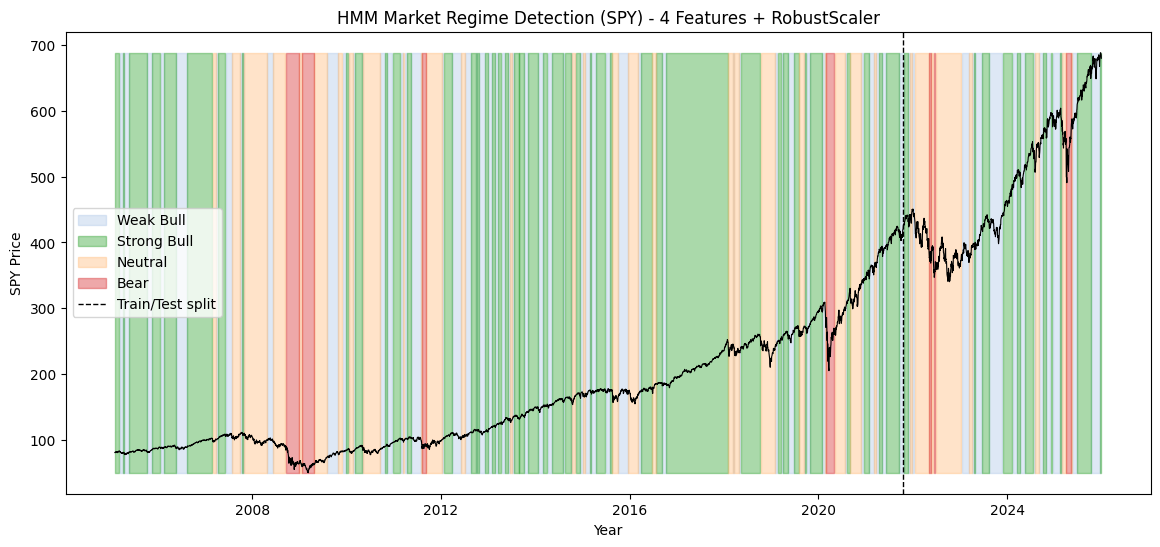

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, close.loc[features.index], color='black', linewidth=0.8, zorder=3)

for state in range(4):
    mask = (states == state)
    plt.fill_between(features.index, 
                     close.loc[features.index].min(), 
                     close.loc[features.index].max(),
                     where=mask, alpha=0.4, color = colors[state],
                     label=state_labels[state], zorder=1)
    
split_date = features.index[split]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1, label='Train/Test split')
plt.legend()
plt.title('HMM Market Regime Detection (SPY) - 4 Features + RobustScaler')
plt.xlabel('Year')
plt.ylabel('SPY Price')
plt.tight_layout()
plt.show()

In [41]:
for state in range(4):
    regime_returns = features['Returns'].values[states == state]
    print(f"{state_labels[state]:11s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Weak Bull   | Mean: 0.0005 | Std: 0.0086 | Days: 1596
Strong Bull | Mean: 0.0009 | Std: 0.0054 | Days: 2095
Neutral     | Mean: 0.0000 | Std: 0.0142 | Days: 1320
Bear        | Mean: -0.0022 | Std: 0.0354 | Days: 252


In [45]:
results = []

for n in range(2, 7):
    m = GaussianHMM(n_components=n, covariance_type='full', n_iter=200, random_state=42)
    m.fit(scaled_train)

    aic = m.aic(all_scaled)
    bic = m.bic(all_scaled)
    results.append((n, aic, bic))
    print(f"n={n} | AIC: {aic:.2f} | BIC: {bic:.2f} | Converged: {m.monitor_.converged}")

n=2 | AIC: 49413.70 | BIC: 49617.32 | Converged: True
n=3 | AIC: 44049.72 | BIC: 44378.14 | Converged: True
n=4 | AIC: 40943.54 | BIC: 41409.90 | Converged: True
n=5 | AIC: 38595.11 | BIC: 39212.54 | Converged: True
n=6 | AIC: 37008.57 | BIC: 37790.22 | Converged: True


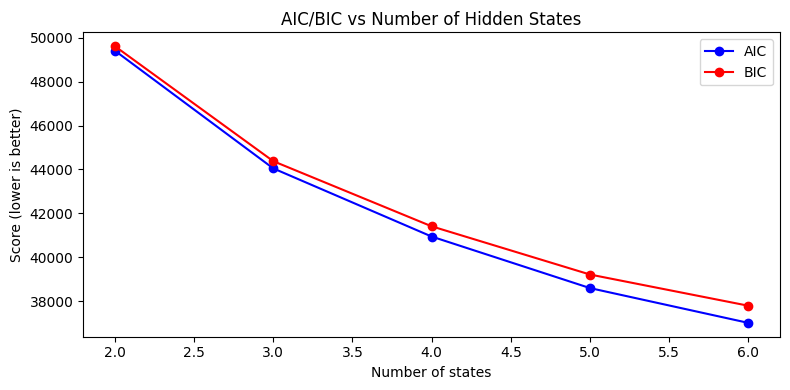

In [48]:
ns = [r[0] for r in results]
aics = [r[1] for r in results]
bics = [r[2] for r in results]

plt.figure(figsize=(8,4))
plt.plot(ns, aics, 'o-', label='AIC', color='blue')
plt.plot(ns, bics, 'o-', label='BIC', color='red')
plt.xlabel('Number of states')
plt.ylabel('Score (lower is better)')
plt.title("AIC/BIC vs Number of Hidden States")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#State persistence 
def compute_persistence(states, state_labels):
    persistence = {label: [] for label in state_labels.values()}

    current_state = states[0]
    count = 1
    
    for i in range(1, len(states)):
        if states[i] == current_state:
            count += 1
        else:
            persistence[state_labels[current_state]].append(count)
            current_state = states[i]
            count = 1

    persistence[state_labels[current_state]].append(count)

    print("State Persistence (average consecutive days per regime):")
    for label, runs in persistence.items():
        print(f"{label:12s} | Avg: {np.mean(runs):.1f} days | Max: {np.max(runs)} days | Transitions: {len(runs)}")

In [62]:
#log-likelihood on train vs test set
scaled_test = scaler.transform(test_features)

train_score = model.score(scaled_train) / len(scaled_train)
test_score = model.score(scaled_test) / len(scaled_test)

print(f"Train log-likelihood (per sample): {train_score:.4f}")
print(f"Test log-likelihood (per sample): {test_score:.4f}")
print(f"Difference: {abs(train_score - test_score):.4f}")

if (abs(train_score - test_score) < 0.5): # heuristic value, not in any standard
    print(f"\nModel generalizes well - train and test scores are close")
elif test_score < train_score - 0.5:
    print("\nPossible overfitting - test score is significantly lower than train")

Train log-likelihood (per sample): -3.8418
Test log-likelihood (per sample): -4.0226
Difference: 0.1808

Model generalizes well - train and test scores are close


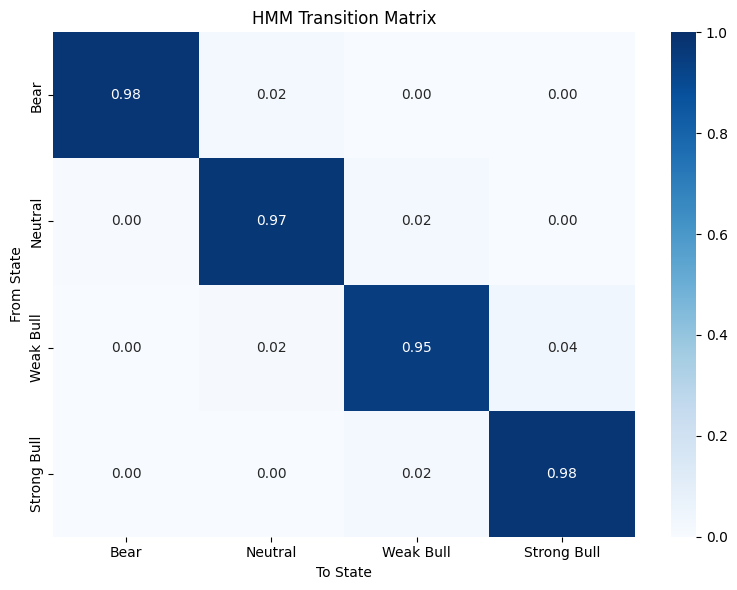

In [80]:
ordered_labels = [state_labels[sorted_states[i]] for i in range(4)]

transmat = model.transmat_

idx = [sorted_states[i] for i in range(4)]
reordered = transmat[np.ix_(idx, idx)]

plt.figure(figsize=(8, 6))
sns.heatmap(reordered,
            annot=True,
            fmt='.2f',
            xticklabels=ordered_labels,
            yticklabels=ordered_labels,
            cmap='Blues',
            vmin=0, vmax=1)

plt.title("HMM Transition Matrix")
plt.ylabel("From State")
plt.xlabel("To State")
plt.tight_layout()
plt.show()

In [ ]:
# Regime Prediction using forward algorithm + transition matrix
def predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=1):
    # Scale the recent data
    scaled = scaler.transform(recent_data)

    # Forward algorithm - get current state probability distribution
    # model.predict_proba() returns P(state|observations) for each timestep 
    state_probs = model.predict_proba(scaled)

    # Take the last timestep's probabilities as current state
    current_probs = state_probs[-1]

    # Project k steps ahead using the transition matrix
    future_probs = current_probs @ np.linalg.matrix_power(model.transmat_, k)

    #Map to labels
    predicted_state = np.argmax(future_probs)
    predicted_label = state_labels[predicted_state]

    print(f"Prediction {k} day(s) ahead:")
    print(f"Predicted regime: {predicted_label}")
    print(f"\nFull probability distribution:")
    for i in range(4):
        label = state_labels[sorted_states[i]]
        prob = future_probs[sorted_states[i]]
        print(f"  {label:.12s}: {prob:.4f} ({prob*100:.4f}%)")
    
    return predicted_label, future_probs

#Use last 60 days as recent data
recent_data = features.iloc[-60:]

#Predict 1, 5, 10 days ahead
for k in [1, 5, 10]:
    print(f"{'='*40}")
    predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=k)
    print()

Prediction 1 day(s) ahead:
Predicted regime: Strong Bull

Full probability distribution:
  Bear: 0.0000 (0.0000%)
  Neutral: 0.0035 (0.3520%)
  Weak Bull: 0.0218 (2.1768%)
  Strong Bull: 0.9747 (97.4712%)

Prediction 5 day(s) ahead:
Predicted regime: Strong Bull

Full probability distribution:
  Bear: 0.0002 (0.0161%)
  Neutral: 0.0187 (1.8738%)
  Weak Bull: 0.0924 (9.2395%)
  Strong Bull: 0.8887 (88.8706%)

Prediction 10 day(s) ahead:
Predicted regime: Strong Bull

Full probability distribution:
  Bear: 0.0007 (0.0726%)
  Neutral: 0.0390 (3.9028%)
  Weak Bull: 0.1553 (15.5288%)
  Strong Bull: 0.8050 (80.4958%)



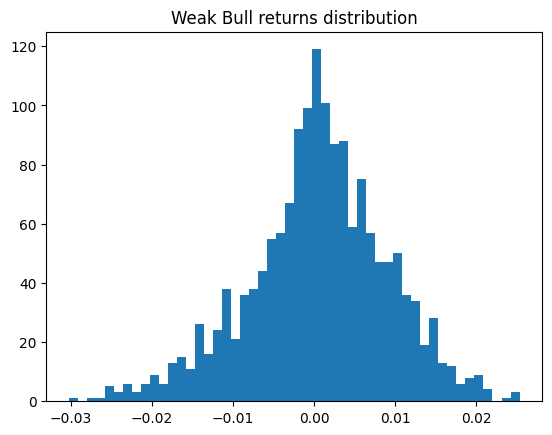

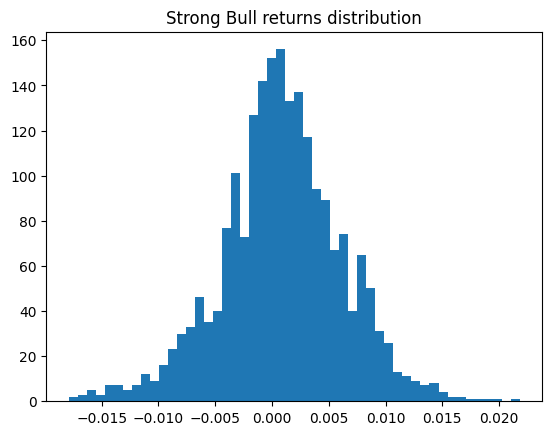

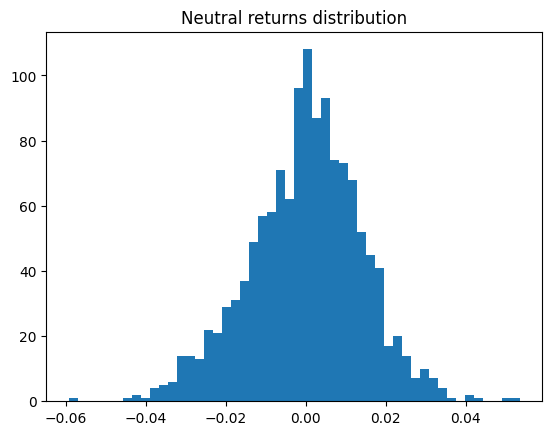

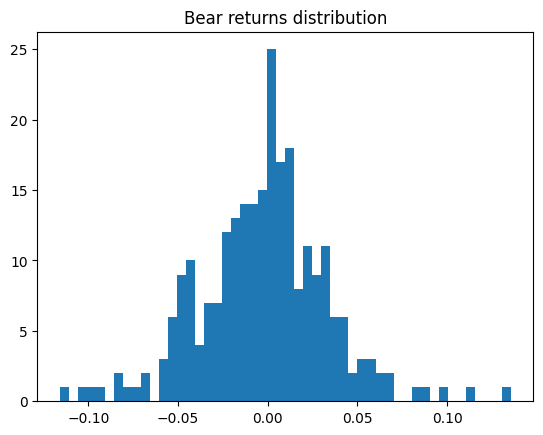

In [88]:
#Check if returns within each state look Gaussian
for state in range(4):
    regime_returns = features['Returns'].values[states == state]
    plt.hist(regime_returns, bins=50)
    plt.title(f"{state_labels[state]} returns distribution")
    plt.show()